<a href="https://colab.research.google.com/github/SharonDarla/Web-Data-Scrapping/blob/main/WEB_DATA_SCRAPPING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install xlsxwriter

In [4]:
pip install nltk pandas beautifulsoup4 requests

In [6]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [7]:
pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 82.5 MB/s eta 0:00:00


In [8]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import textstat
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
import os
import zipfile

In [11]:
from google.colab import files
uploaded = files.upload()

Saving stopwords.zip to stopwords (1).zip


In [13]:
from google.colab import files
uploaded = files.upload()

Saving 4289437-1bb4d7f9ee82150f339f09b5b1a0e6823d633958.zip to 4289437-1bb4d7f9ee82150f339f09b5b1a0e6823d633958.zip


In [14]:
from google.colab import files
uploaded = files.upload()

Saving negetive-words.txt.zip to negetive-words.txt.zip


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os
os.listdir('/content/drive/MyDrive/data_scrapping_project_darla/')

['StopWords-20250615T145903Z-1-001.zip',
 'MasterDictionary-20240709T030236Z-001.zip',
 'unzipped_stopwords',
 'Input.xlsx']

In [21]:
def extract_article(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')

    # Print the HTML content for inspection
    print(soup.prettify())

    # Retrieve the article's title, handling the case when it's not found
    title_element = soup.find('h1', class_='entry-title')
    if title_element:
        title = title_element.get_text()
    else:
        title = "Title not found"
        print("Warning: Could not find article title.")

    # Retrieve the article's content
    article_body = soup.find('div', class_='td-post-content')
    paragraphs = article_body.find_all('p')
    article_text = "\n".join([p.get_text() for p in paragraphs])

    return title, article_text

# Function to save article content to a text file
def save_article(url_id, title, article_text):
    filename = f"{url_id}.txt"
    with open(filename, 'w', encoding='utf-8') as file:
        file.write(title + "\n\n" + article_text)

# Function to load stop words from a directory
def load_stop_words(directory):
    stop_words = set()
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if os.path.isfile(filepath): # Ensure the path is a file
            with open(filepath, 'r', encoding='utf-8') as file:
                stop_words.update(file.read().split())
    return stop_words

# Function to load positive and negative words, excluding stop words
def load_sentiment_words(positive_file, negative_file, stop_words):
    with open(positive_file, 'r', encoding='utf-8', errors='replace') as file: # Handle encoding errors in the positive words file
        positive_words = set(file.read().split()) - stop_words

    with open(negative_file, 'r', encoding='latin-1', errors='replace') as file: # Handle encoding errors in the negative words file
        negative_words = set(file.read().split()) - stop_words

    return positive_words, negative_words

# Functions for text analysis
def calculate_positive_score(text, positive_words):
    words = word_tokenize(text)
    positive_score = sum(1 for word in words if word.lower() in positive_words)
    return positive_score

def calculate_negative_score(text, negative_words):
    words = word_tokenize(text)
    negative_score = sum(1 for word in words if word.lower() in negative_words)
    return negative_score

def calculate_polarity_score(positive_score, negative_score):
    return (positive_score - negative_score) / ((positive_score + negative_score) + 0.000001)

def calculate_subjectivity_score(positive_score, negative_score, text):
    words = word_tokenize(text)
    total_words = len(words)
    return (positive_score + negative_score) / (total_words + 0.000001)

def calculate_avg_sentence_length(text):
    sentences = sent_tokenize(text)
    words = word_tokenize(text)
    avg_sentence_length = len(words) / len(sentences)
    return avg_sentence_length

def calculate_percentage_complex_words(text):
    words = word_tokenize(text)
    complex_words = [word for word in words if textstat.syllable_count(word) > 2]
    percentage_complex_words = (len(complex_words) / len(words)) * 100
    return percentage_complex_words

def calculate_fog_index(avg_sentence_length, percentage_complex_words):
    return 0.4 * (avg_sentence_length + percentage_complex_words)

def calculate_complex_word_count(text):
    words = word_tokenize(text)
    complex_words = [word for word in words if textstat.syllable_count(word) > 2]
    return len(complex_words)

def calculate_word_count(text):
    words = word_tokenize(text)
    return len(words)

def calculate_syllables_per_word(text):
    words = word_tokenize(text)
    syllables = sum(textstat.syllable_count(word) for word in words)
    syllables_per_word = syllables / len(words)
    return syllables_per_word

def calculate_personal_pronouns(text):
    pronouns = re.findall(r'\b(I|we|my|ours|us)\b', text, re.I)
    return len(pronouns)

def calculate_avg_word_length(text):
    words = word_tokenize(text)
    total_characters = sum(len(word) for word in words)
    avg_word_length = total_characters / len(words)
    return avg_word_length


In [22]:
# Unzip and extract stop words files
import zipfile
stop_words_zip = '/content/drive/MyDrive/data_scrapping_project_darla/StopWords-20250615T145903Z-1-001.zip'
stop_words_directory = '/content/drive/MyDrive/data_scrapping_project_darla/unzipped_stopwords/'
with zipfile.ZipFile(stop_words_zip, 'r') as zip_ref:
    zip_ref.extractall(stop_words_directory)

In [29]:
# Paths for sentiment words files
import pandas as pd
master_dict_zip = '/content/drive/MyDrive/data_scrapping_project_darla/MasterDictionary-20240709T030236Z-001.zip'
extract_to_master = '/content/drive/MyDrive/data_scrapping_project_darla/unzipped_masterdict/MasterDictionary'

os.makedirs(extract_to_master, exist_ok=True)

with zipfile.ZipFile(master_dict_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_to_master)

# Now load positive and negative words
positive_words_file = os.path.join(extract_to_master, 'positive-words.txt')
negative_words_file = os.path.join(extract_to_master, 'negative-words.txt')

# Load stop words
stop_words = load_stop_words(stop_words_directory)

# Load positive and negative sentiment words
positive_words, negative_words = load_sentiment_words(positive_words_file, negative_words_file, stop_words)

# Read the input Excel file containing URLs
input_file = '/content/drive/MyDrive/data_scrapping_project_darla/Input.xlsx'
df = pd.read_excel(input_file)

# Prepare a DataFrame to store the output
output_df = pd.DataFrame(columns=[
    'URL_ID', 'URL', 'POSITIVE SCORE', 'NEGATIVE SCORE', 'POLARITY SCORE', 'SUBJECTIVITY SCORE',
    'AVG SENTENCE LENGTH', 'PERCENTAGE OF COMPLEX WORDS', 'FOG INDEX', 'AVG NUMBER OF WORDS PER SENTENCE',
    'COMPLEX WORD COUNT', 'WORD COUNT', 'SYLLABLE PER WORD', 'PERSONAL PRONOUNS', 'AVG WORD LENGTH'
])

In [31]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [32]:

# Process each URL
for index, row in df.iterrows():
    url_id = row['URL_ID']
    url = row['URL']

    title, article_text = extract_article(url)
    save_article(url_id, title, article_text)

    positive_score = calculate_positive_score(article_text, positive_words)
    negative_score = calculate_negative_score(article_text, negative_words)
    polarity_score = calculate_polarity_score(positive_score, negative_score)
    subjectivity_score = calculate_subjectivity_score(positive_score, negative_score, article_text)
    avg_sentence_length = calculate_avg_sentence_length(article_text)
    percentage_complex_words = calculate_percentage_complex_words(article_text)
    fog_index = calculate_fog_index(avg_sentence_length, percentage_complex_words)
    complex_word_count = calculate_complex_word_count(article_text)
    word_count = calculate_word_count(article_text)
    syllables_per_word = calculate_syllables_per_word(article_text)
    personal_pronouns = calculate_personal_pronouns(article_text)
    avg_word_length = calculate_avg_word_length(article_text)

    # Create a new row with the analyzed data
    new_row = {
        'URL_ID': url_id,
        'URL': url,  # Just save the plain URL, we'll handle the hyperlink in Excel writer
        'POSITIVE SCORE': positive_score,
        'NEGATIVE SCORE': negative_score,
        'POLARITY SCORE': polarity_score,
        'SUBJECTIVITY SCORE': subjectivity_score,
        'AVG SENTENCE LENGTH': avg_sentence_length,
        'PERCENTAGE OF COMPLEX WORDS': percentage_complex_words,
        'FOG INDEX': fog_index,
        'AVG NUMBER OF WORDS PER SENTENCE': avg_sentence_length,
        'COMPLEX WORD COUNT': complex_word_count,
        'WORD COUNT': word_count,
        'SYLLABLE PER WORD': syllables_per_word,
        'PERSONAL PRONOUNS': personal_pronouns,
        'AVG WORD LENGTH': avg_word_length
    }
    output_df = pd.concat([output_df, pd.DataFrame([new_row])], ignore_index=True)

# Save the output DataFrame to an Excel file with hyperlinks
output_file = 'Output Data Structure.xlsx'
writer = pd.ExcelWriter(output_file, engine='xlsxwriter')
output_df.to_excel(writer, sheet_name='Sheet1', index=False)

# Access the XlsxWriter workbook and worksheet objects
workbook = writer.book
worksheet = writer.sheets['Sheet1']

# Add hyperlinks
for row_num, url in enumerate(output_df['URL'], start=1):
    worksheet.write_url(row_num, 1, url)

# Close the writer and save the Excel file
writer.close()

print("Text analysis and saving complete.")

<!--
		        Error: <strong class="td-wp-booster-title">wp_booster error:</strong><br>td_api_base::mark_used_on_page : a component with the ID: single_template_7 is not set.<br>/home4/blacksan/public_html/insights/wp-content/plugins/td-composer/legacy/common/wp_booster/td_api.php (rara-error)
		    -->
<!--
		        Error: <strong class="td-wp-booster-title">wp_booster error:</strong><br>td_api_base::get_key : a component with the ID: <b>single_template_7</b> Key: <b>file</b> is not set.<br>/home4/blacksan/public_html/insights/wp-content/plugins/td-composer/legacy/common/wp_booster/td_api.php (rara-error)
		    -->
<!--
		        Error: <strong class="td-wp-booster-title">wp_booster error:</strong><br>The path  of the single_template_7 template not found. Did you disable a tagDiv plugin?<br>/home4/blacksan/public_html/insights/wp-content/plugins/td-composer/legacy/common/wp_booster/td_api.php (rara-error)
		    -->
<!DOCTYPE html >
<html lang="en-US">
 <head>
  <meta charset="utf-8"

<ipython-input-32-661752036>:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_df = pd.concat([output_df, pd.DataFrame([new_row])], ignore_index=True)


Streaming output truncated to the last 5000 lines.
				}.tdi_51.td-no-subcats .td_module_wrap{
					width: 20%;
					float: left;
				}.td-md-is-safari .tdi_51.td-no-subcats .td_module_wrap{
				    margin-right: -1px;
				}.tdi_51 .td_module_wrap:nth-child(4n+1){
					clear: both;
				}.tdi_51 .td_module_wrap:nth-last-child(-n+4){
					margin-bottom: 0;
					padding-bottom: 0;
				}.tdi_51 .td_module_wrap:nth-last-child(-n+4) .td-module-container:before{
					display: none;
				}.tdi_51 .td_module_wrap{
					padding-left: 11px;
					padding-right: 11px;
				
					padding-bottom: 13px;
					margin-bottom: 13px;
				
			        display: flex;
			        flex-direction: column;
			    }.tdi_51 .td_block_inner{
					margin-left: -11px;
					margin-right: -11px;
				
			        display: flex;
			        flex-wrap: wrap;
			    }.tdi_51 .td-module-container:before{
					bottom: -13px;
				
					border-color: #eaeaea;
				}.tdi_51 .td-module-container{
				    border-color: #eaeaea;
				
			

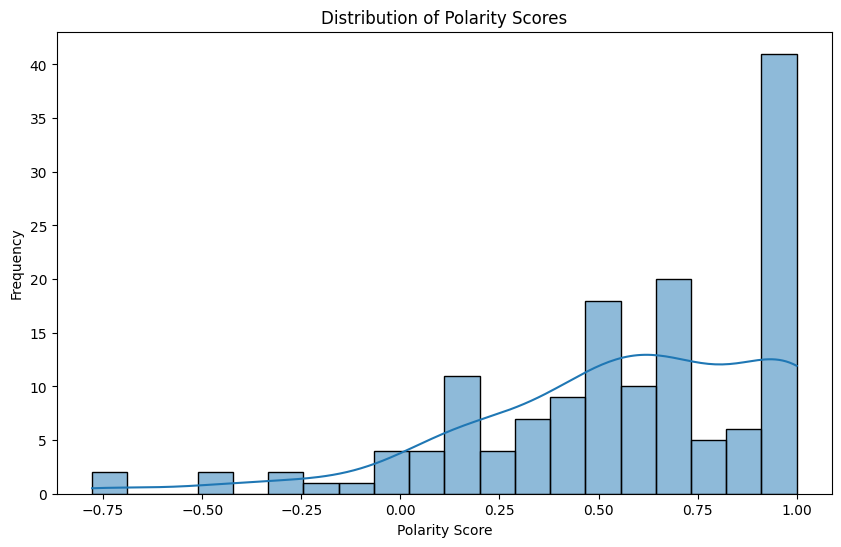

In [33]:
# A histogram of the Polarity Scores to see the distribution of sentiment across the articles.

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(output_df['POLARITY SCORE'], bins=20, kde=True)
plt.title('Distribution of Polarity Scores')
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')
plt.show()

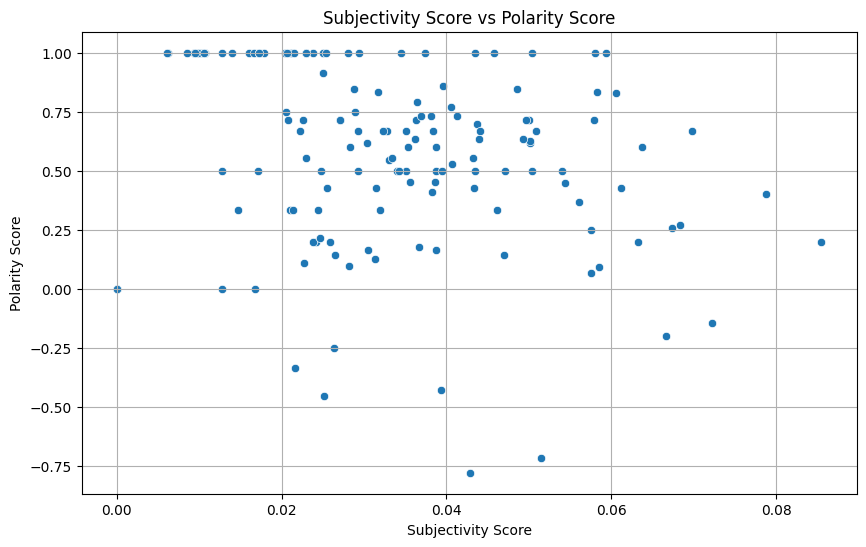

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of Subjectivity vs Polarity Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SUBJECTIVITY SCORE', y='POLARITY SCORE', data=output_df)
plt.title('Subjectivity Score vs Polarity Score')
plt.xlabel('Subjectivity Score')
plt.ylabel('Polarity Score')
plt.grid(True)
plt.show()

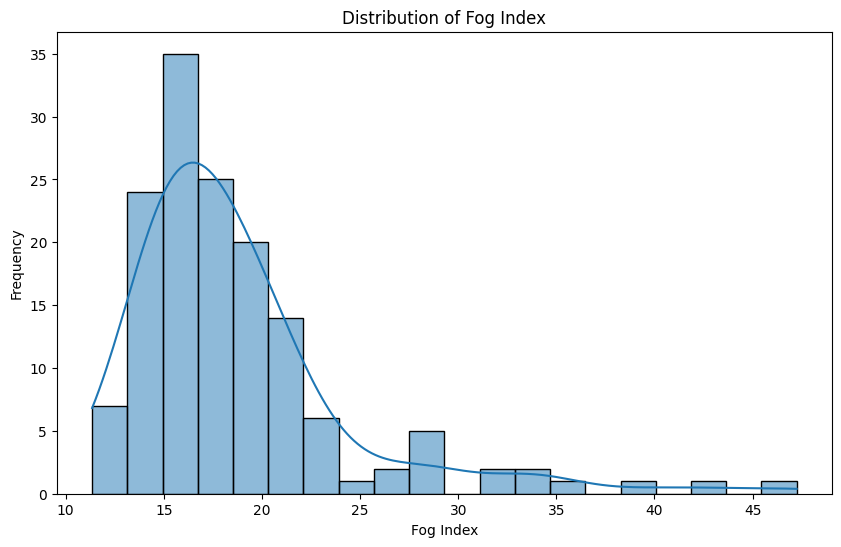

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram of the Fog Index
plt.figure(figsize=(10, 6))
sns.histplot(output_df['FOG INDEX'], bins=20, kde=True)
plt.title('Distribution of Fog Index')
plt.xlabel('Fog Index')
plt.ylabel('Frequency')
plt.show()

In [36]:
from google.colab import files

files.download('Output Data Structure.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>